# IEEE-CIS Data Preparation and EDA

## 1. Project Context

This reproducible notebook prepares Kaggle IEEE-CIS Fraud Detection data for a downstream **Risk Scoring Engine** that will assign 0–100 transaction risk scores.

**Scope:** data understanding, quality, preparation, EDA, feature engineering, drift, and readiness. **Explicitly out of scope:** model training, tuning, comparison/evaluation, SMOTE or any re/under/oversampling, threshold optimization, and SHAP.


In [3]:
from __future__ import annotations
import gc, json, logging, os, random, subprocess, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy import stats
warnings.filterwarnings("ignore", category=FutureWarning)
SEED=42; random.seed(SEED); np.random.seed(SEED)
def resolve_project_root(start_path: Path) -> Path:
    search_paths=[start_path.resolve(), *start_path.resolve().parents]
    for candidate in search_paths:
        if (candidate/"model/scripts/download_data.sh").exists():
            return candidate
    for candidate in search_paths:
        if (candidate/".git").exists():
            return candidate
    return start_path.resolve()
PROJECT_ROOT=resolve_project_root(Path.cwd())
CANDIDATES=[
    PROJECT_ROOT/"data/ieee-fraud-detection",
    PROJECT_ROOT/"model/data/raw",
    PROJECT_ROOT/"data/raw",
    PROJECT_ROOT/"raw",
]
RAW_DATA_DIR=Path(os.environ.get("IEEE_CIS_DATA_DIR", next((str(p) for p in CANDIDATES if p.exists()), str(CANDIDATES[0])))).resolve()
DOWNLOAD_SCRIPT=(PROJECT_ROOT/"model/scripts/download_data.sh").resolve()
OUTPUT_DIR=PROJECT_ROOT/"data/processed/ieee_cis_eda"; OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ID_COL,TARGET_COL,TIME_COL="TransactionID","isFraud","TransactionDT"
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
def ensure_ieee_cis_files(required_files, raw_data_dir=RAW_DATA_DIR, auto_download=True):
    raw_data_dir.mkdir(parents=True, exist_ok=True)
    missing=[name for name in required_files if not (raw_data_dir/name).exists()]
    if not missing:
        return
    if auto_download and DOWNLOAD_SCRIPT.exists():
        logging.info("Missing %s. Attempting dataset download via %s", missing, DOWNLOAD_SCRIPT)
        env=os.environ.copy()
        env.setdefault("IEEE_CIS_DATA_DIR", str(raw_data_dir))
        try:
            subprocess.run(["bash", str(DOWNLOAD_SCRIPT)], check=True, cwd=PROJECT_ROOT, env=env)
        except subprocess.CalledProcessError as exc:
            logging.warning("Automatic dataset download failed with exit code %s", exc.returncode)
    missing=[name for name in required_files if not (raw_data_dir/name).exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing {missing} in {raw_data_dir}. "
            "The notebook attempted an automatic Kaggle download but the files are still unavailable. "
            "Requirements: join the Kaggle competition, install the kaggle CLI, and configure ~/.kaggle/kaggle.json or KAGGLE_USERNAME/KAGGLE_KEY. "
            f"Manual fallback: bash {DOWNLOAD_SCRIPT}"
        )
print(json.dumps({"raw_data_dir":str(RAW_DATA_DIR),"output_dir":str(OUTPUT_DIR),"seed":SEED},indent=2))


{
  "raw_data_dir": "D:\\MSE\\16. Big Data\\Fraud-Detection-Score-Risk\\data\\raw",
  "output_dir": "D:\\MSE\\16. Big Data\\Fraud-Detection-Score-Risk\\data\\processed\\ieee_cis_eda",
  "seed": 42
}


## 2. Environment Setup

The notebook discovers `data/ieee-fraud-detection` first, then `model/data/raw`, `data/raw`, `raw`, or `IEEE_CIS_DATA_DIR`, will attempt an automatic Kaggle download when the four IEEE-CIS CSVs are missing, preserves loaded raw frames, and writes all derived outputs to `data/processed/ieee_cis_eda`.


In [4]:
required=["train_transaction.csv","train_identity.csv","test_transaction.csv","test_identity.csv"]
ensure_ieee_cis_files(required)
paths={x[:-4]:RAW_DATA_DIR/x for x in required}
train_transaction_raw=pd.read_csv(paths["train_transaction"], low_memory=False)
train_identity_raw=pd.read_csv(paths["train_identity"], low_memory=False)
test_transaction_raw=pd.read_csv(paths["test_transaction"], low_memory=False)
test_identity_raw=pd.read_csv(paths["test_identity"], low_memory=False)
assert TARGET_COL in train_transaction_raw and TARGET_COL not in test_transaction_raw
print("Raw data loaded unchanged.")


INFO: Missing ['train_transaction.csv', 'train_identity.csv', 'test_transaction.csv', 'test_identity.csv']. Attempting dataset download via D:\MSE\16. Big Data\Fraud-Detection-Score-Risk\model\scripts\download_data.sh


FileNotFoundError: Missing ['train_transaction.csv', 'train_identity.csv', 'test_transaction.csv', 'test_identity.csv'] in D:\MSE\16. Big Data\Fraud-Detection-Score-Risk\data\raw. The notebook attempted an automatic Kaggle download but the files are still unavailable. Requirements: join the Kaggle competition, install the kaggle CLI, and configure ~/.kaggle/kaggle.json or KAGGLE_USERNAME/KAGGLE_KEY. Manual fallback: bash D:\MSE\16. Big Data\Fraud-Detection-Score-Risk\model\scripts\download_data.sh

## 3–6. Load Raw Data, Dataset Inventory, Schema/Key Validation, and Merge Audit

The identity join is validated as one-to-one and must preserve the transaction grain.


In [ ]:
def mem_mb(df): return df.memory_usage(deep=True).sum()/2**20
def group(c):
    l=c.lower()
    if c==TARGET_COL:return "target"
    if c in [ID_COL,TIME_COL,"TransactionAmt"]:return "transaction"
    if c=="ProductCD":return "product"
    if l.startswith("card"):return "card"
    if l.startswith("addr"):return "address"
    if "emaildomain" in l:return "email"
    if l.startswith("c") and l[1:].isdigit() and 1<=int(l[1:])<=14:return "count features C1-C14"
    if l.startswith("d") and l[1:].isdigit() and 1<=int(l[1:])<=15:return "time delta features D1-D15"
    if l.startswith("m") and l[1:].isdigit() and 1<=int(l[1:])<=9:return "match features M1-M9"
    if l.startswith("v") and l[1:].isdigit() and 1<=int(l[1:])<=339:return "Vesta features V1-V339"
    if l.startswith("id_"):return "identity features id_01-id_38"
    if c in ["DeviceType","DeviceInfo"]:return "device"
    return "other"
raw={"train_transaction":train_transaction_raw,"train_identity":train_identity_raw,"test_transaction":test_transaction_raw,"test_identity":test_identity_raw}
manifest=pd.DataFrame([{"dataset":n,"path":str(paths[n]),"file_size_mb":paths[n].stat().st_size/2**20,"rows":len(d),"columns":d.shape[1],"memory_mb":mem_mb(d),"dtype_counts":json.dumps(d.dtypes.astype(str).value_counts().to_dict())} for n,d in raw.items()])
display(manifest); manifest.to_csv(OUTPUT_DIR/"data_manifest.csv",index=False)
def checks(tx,ident,name):
    return [{"dataset":name,"check":"transaction_key_nulls","value":int(tx[ID_COL].isna().sum()),"status":"pass" if tx[ID_COL].notna().all() else "fail"},
      {"dataset":name,"check":"transaction_duplicate_keys","value":int(tx[ID_COL].duplicated().sum()),"status":"pass" if tx[ID_COL].is_unique else "fail"},
      {"dataset":name,"check":"identity_duplicate_keys","value":int(ident[ID_COL].duplicated().sum()),"status":"pass" if ident[ID_COL].is_unique else "fail"},
      {"dataset":name,"check":"orphan_identity_records","value":int((~ident[ID_COL].isin(tx[ID_COL])).sum()),"status":"pass" if ident[ID_COL].isin(tx[ID_COL]).all() else "fail"}]
validation=pd.DataFrame(checks(train_transaction_raw,train_identity_raw,"train")+checks(test_transaction_raw,test_identity_raw,"test"))
validation.loc[len(validation)]={"dataset":"train/test","check":"transaction_schema_train_only","value":",".join(sorted(set(train_transaction_raw)-set(test_transaction_raw))),"status":"review"}
validation.loc[len(validation)]={"dataset":"train/test","check":"identity_schemas_equal","value":train_identity_raw.columns.equals(test_identity_raw.columns),"status":"pass" if train_identity_raw.columns.equals(test_identity_raw.columns) else "review"}
display(validation)
assert train_transaction_raw[ID_COL].is_unique and test_transaction_raw[ID_COL].is_unique


,dataset,path,file_size_mb,rows,columns,memory_mb,dtype_counts
0,train_transaction,/tmp/MicrosoftEdgeDownloads/00f2daad-481e-4a91...,651.694362,590540,394,2062.071100,"{""float64"": 376, ""object"": 14, ""int64"": 4}"
1,train_identity,/tmp/MicrosoftEdgeDownloads/00f2daad-481e-4a91...,25.300674,144233,41,143.144178,"{""float64"": 23, ""object"": 17, ""int64"": 1}"
2,test_transaction,/tmp/MicrosoftEdgeDownloads/00f2daad-481e-4a91...,584.788260,506691,393,1771.837384,"{""float64"": 376, ""object"": 14, ""int64"": 3}"
3,test_identity,/tmp/MicrosoftEdgeDownloads/00f2daad-481e-4a91...,24.602090,141907,41,140.084384,"{""float64"": 23, ""object"": 17, ""int64"": 1}"


,dataset,check,value,status
0,train,transaction_key_nulls,0,pass
1,train,transaction_duplicate_keys,0,pass
2,train,identity_duplicate_keys,0,pass
3,train,orphan_identity_records,0,pass
4,test,transaction_key_nulls,0,pass
5,test,transaction_duplicate_keys,0,pass
6,test,identity_duplicate_keys,0,pass
7,test,orphan_identity_records,0,pass
8,train/test,transaction_schema_train_only,isFraud,review
9,train/test,identity_schemas_equal,False,review


## 7–10. Data Profiling, Feature Groups, Missingness, Duplicates, Memory Optimisation

High missingness, rare values, and duplicate candidates are reported—not automatically removed.


In [ ]:
def audited_merge(tx,ident,name):
    before=len(tx); merged=tx.merge(ident,on=ID_COL,how="left",validate="one_to_one",indicator="_merge")
    merged["has_identity"]=(merged["_merge"]=="both").astype("int8")
    audit={"dataset":name,"join":"left one_to_one","transaction_rows_before":before,"rows_after":len(merged),"row_delta":len(merged)-before,"duplicate_ids_after":int(merged[ID_COL].duplicated().sum()),"identity_coverage_pct":100*merged.has_identity.mean()}
    audit["status"]="pass" if audit["row_delta"]==0 and audit["duplicate_ids_after"]==0 else "fail"
    assert audit["status"]=="pass"
    return merged.drop(columns="_merge"),audit
train_merged,a1=audited_merge(train_transaction_raw.copy(),train_identity_raw.copy(),"train")
test_merged,a2=audited_merge(test_transaction_raw.copy(),test_identity_raw.copy(),"test")
merge_audit=pd.DataFrame([a1,a2]); display(merge_audit); merge_audit.to_csv(OUTPUT_DIR/"merge_audit.csv",index=False)


,dataset,join,transaction_rows_before,rows_after,row_delta,duplicate_ids_after,identity_coverage_pct,status
0,train,left one_to_one,590540,590540,0,0,24.423917,pass
1,test,left one_to_one,506691,506691,0,0,28.006615,pass


## 12. Risk-Focused EDA

These charts are exploratory evidence only. Findings are printed from the actual loaded data below each chart.


In [ ]:
def profile(df):
    out=[]
    for c in df:
        s=df[c]; num=pd.api.types.is_numeric_dtype(s); u=s.nunique(dropna=True)
        out.append({"column":c,"dtype":str(s.dtype),"missing_count":int(s.isna().sum()),"missing_pct":100*s.isna().mean(),"unique_count":u,"cardinality_ratio":u/len(s),"minimum":s.min() if num and s.notna().any() else np.nan,"maximum":s.max() if num and s.notna().any() else np.nan,"mean":s.mean() if num else np.nan,"median":s.median() if num else np.nan,"std":s.std() if num else np.nan})
    p=pd.DataFrame(out); p["feature_group"]=p.column.map(group)
    p["is_constant"]=p.unique_count<=1; p["is_near_constant"]=(p.cardinality_ratio<.0001)&(p.unique_count>1)
    p["is_high_cardinality"]=p.cardinality_ratio>.1
    p["is_id_like"]=p.column.str.contains("transactionid|deviceinfo|_id$",case=False,regex=True)| (p.cardinality_ratio>.8)
    return p
data_dictionary=profile(train_merged); data_dictionary.to_csv(OUTPUT_DIR/"data_dictionary.csv",index=False)
feature_group_summary=data_dictionary.groupby("feature_group",as_index=False).agg(columns=("column","count"),missing_pct=("missing_pct","mean"),high_cardinality=("is_high_cardinality","sum"),constant=("is_constant","sum"))
display(feature_group_summary.sort_values("columns",ascending=False))
display(data_dictionary.query("is_constant or is_near_constant or is_high_cardinality or is_id_like").head(30))
def missing_report(tr,te):
    rows=[]
    for c in tr:
        if c==TARGET_COL:continue
        tm=100*tr[c].isna().mean(); sm=100*te[c].isna().mean() if c in te else np.nan
        rows.append({"column":c,"feature_group":group(c),"train_missing_pct":tm,"test_missing_pct":sm,"missing_delta_pp":sm-tm,"fraud_missing_pct":100*tr.loc[tr[TARGET_COL].eq(1),c].isna().mean(),"nonfraud_missing_pct":100*tr.loc[tr[TARGET_COL].eq(0),c].isna().mean()})
    r=pd.DataFrame(rows); r["fraud_missing_delta_pp"]=r.fraud_missing_pct-r.nonfraud_missing_pct
    r["interpretation"]=np.where(r.feature_group.isin(["identity features id_01-id_38","device"]),"likely structural/coverage-dependent; verify","review for quality or population shift")
    return r
missing_value_report=missing_report(train_merged,test_merged); missing_value_report.to_csv(OUTPUT_DIR/"missing_value_report.csv",index=False)
display(missing_value_report.sort_values("train_missing_pct",ascending=False).head(25))
fam=missing_value_report.groupby("feature_group",as_index=False).mean(numeric_only=True); display(fam)
semantic=[c for c in ["TransactionAmt","card1","card2","card3","card4","card5","ProductCD","addr1","addr2",TIME_COL] if c in train_merged]
duplicate_report=pd.DataFrame([{"check":"exact_duplicate_rows_excluding_key","count":int(train_merged.drop(columns=ID_COL).duplicated().sum()),"action":"review; retain raw"},
{"check":"duplicate_TransactionID","count":int(train_merged[ID_COL].duplicated().sum()),"action":"must remain zero"},
{"check":"semantic_duplicate_candidates","count":int(train_merged.duplicated(semantic,keep=False).sum()),"action":"analyze repeated patterns; do not delete"}])
display(duplicate_report); duplicate_report.to_csv(OUTPUT_DIR/"duplicate_report.csv",index=False)


,feature_group,columns,missing_pct,high_cardinality,constant
0,Vesta features V1-V339,339,43.038469,0,0
6,identity features id_01-id_38,38,84.823271,1,0
11,time delta features D1-D15,15,58.151263,0,0
3,count features C1-C14,14,0.000000,0,0
7,match features M1-M9,9,49.923328,0,0
2,card,6,0.505328,0,0
8,other,3,51.093575,0,0
12,transaction,3,0.000000,2,0
1,address,2,11.126427,0,0
4,device,2,78.030616,0,0


,column,dtype,missing_count,missing_pct,unique_count,cardinality_ratio,minimum,maximum,mean,median,std,feature_group,is_constant,is_near_constant,is_high_cardinality,is_id_like
0,TransactionID,int64,0,0.000000,590540,1.000000,2987000.0,3.577539e+06,3.282270e+06,3.282270e+06,1.704744e+05,transaction,False,False,True,True
1,isFraud,int64,0,0.000000,2,0.000003,0.0,1.000000e+00,3.499001e-02,0.000000e+00,1.837546e-01,target,False,True,False,False
2,TransactionDT,int64,0,0.000000,573349,0.970889,86400.0,1.581113e+07,7.372311e+06,7.306528e+06,4.617224e+06,transaction,False,False,True,True
4,ProductCD,object,0,0.000000,5,0.000008,NaN,NaN,NaN,NaN,NaN,product,False,True,False,False
8,card4,object,1577,0.267044,4,0.000007,NaN,NaN,NaN,NaN,NaN,card,False,True,False,False
10,card6,object,1571,0.266028,4,0.000007,NaN,NaN,NaN,NaN,NaN,card,False,True,False,False
15,P_emaildomain,object,94456,15.994852,59,0.000100,NaN,NaN,NaN,NaN,NaN,email,False,True,False,False
19,C3,float64,0,0.000000,27,0.000046,0.0,2.600000e+01,5.643987e-03,0.000000e+00,1.505356e-01,count features C1-C14,False,True,False,False
39,D9,float64,515614,87.312290,24,0.000041,0.0,9.583330e-01,5.610571e-01,6.666660e-01,3.168796e-01,time delta features D1-D15,False,True,False,False
46,M1,object,271100,45.907136,2,0.000003,NaN,NaN,NaN,NaN,NaN,match features M1-M9,False,True,False,False


,column,feature_group,train_missing_pct,test_missing_pct,missing_delta_pp,fraud_missing_pct,nonfraud_missing_pct,fraud_missing_delta_pp,interpretation
416,id_24,identity features id_01-id_38,99.196159,NaN,NaN,98.054494,99.237555,-1.183061,likely structural/coverage-dependent; verify
417,id_25,identity features id_01-id_38,99.130965,NaN,NaN,97.981900,99.172628,-1.190728,likely structural/coverage-dependent; verify
400,id_08,identity features id_01-id_38,99.127070,NaN,NaN,97.938344,99.170172,-1.231828,likely structural/coverage-dependent; verify
399,id_07,identity features id_01-id_38,99.127070,NaN,NaN,97.938344,99.170172,-1.231828,likely structural/coverage-dependent; verify
413,id_21,identity features id_01-id_38,99.126393,NaN,NaN,97.938344,99.169470,-1.231126,likely structural/coverage-dependent; verify
418,id_26,identity features id_01-id_38,99.125715,NaN,NaN,97.943183,99.168593,-1.225409,likely structural/coverage-dependent; verify
414,id_22,identity features id_01-id_38,99.124699,NaN,NaN,97.938344,99.167715,-1.229371,likely structural/coverage-dependent; verify
419,id_27,identity features id_01-id_38,99.124699,NaN,NaN,97.938344,99.167715,-1.229371,likely structural/coverage-dependent; verify
415,id_23,identity features id_01-id_38,99.124699,NaN,NaN,97.938344,99.167715,-1.229371,likely structural/coverage-dependent; verify
13,dist2,other,93.628374,92.809030,-0.819344,81.943571,94.052050,-12.108479,review for quality or population shift


,feature_group,train_missing_pct,test_missing_pct,missing_delta_pp,fraud_missing_pct,nonfraud_missing_pct,fraud_missing_delta_pp
0,Vesta features V1-V339,43.038469,38.620295,-4.418174,35.138978,43.324894,-8.185917
1,address,11.126427,12.948523,1.822096,37.463098,10.171493,27.291605
2,card,0.505328,0.733386,0.228057,0.606559,0.501658,0.104901
3,count features C1-C14,0.000000,0.067483,0.067483,0.000000,0.000000,0.000000
4,device,78.030616,75.133957,-2.896659,52.044718,78.972831,-26.928113
5,email,46.373235,43.420250,-2.952984,29.584281,46.981980,-17.397699
6,identity features id_01-id_38,84.823271,NaN,NaN,66.206441,85.498293,-19.291852
7,match features M1-M9,49.923328,42.569425,-7.353903,64.953997,49.378336,15.575662
8,other,51.093575,50.094436,-0.999139,52.977141,51.025280,1.951861
9,product,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,check,count,action
0,exact_duplicate_rows_excluding_key,3,review; retain raw
1,duplicate_TransactionID,0,must remain zero
2,semantic_duplicate_candidates,106,analyze repeated patterns; do not delete


## 13–15. Temporal, Outlier/Rare Pattern, and Train–Test Drift Analysis

`TransactionDT` is a competition-relative time proxy. Temporal patterns and drift make random validation splits inappropriate.


In [ ]:
def optimize(df):
    out=df.copy()
    for c in out:
        if pd.api.types.is_integer_dtype(out[c]):out[c]=pd.to_numeric(out[c],downcast="integer")
        elif pd.api.types.is_float_dtype(out[c]):out[c]=pd.to_numeric(out[c],downcast="float")
        elif pd.api.types.is_object_dtype(out[c]) and out[c].nunique(dropna=False)/len(out)<.5:out[c]=out[c].astype("category")
    return out
train_merged_opt,test_merged_opt=optimize(train_merged),optimize(test_merged)
memory_comparison=pd.DataFrame({"dataset":["train","test"],"before_mb":[mem_mb(train_merged),mem_mb(test_merged)],"after_mb":[mem_mb(train_merged_opt),mem_mb(test_merged_opt)]})
memory_comparison["reduction_pct"]=100*(1-memory_comparison.after_mb/memory_comparison.before_mb)
display(memory_comparison)
train_merged_opt.to_parquet(OUTPUT_DIR/"train_merged.parquet",index=False); test_merged_opt.to_parquet(OUTPUT_DIR/"test_merged.parquet",index=False)


,dataset,before_mb,after_mb,reduction_pct
0,train,2514.537674,924.978305,63.214776
1,test,2164.582572,793.226011,63.354320


## 16–17. Cleaning, Standardization, and Leakage-Safe Feature Engineering

String cleaning is deterministic and target-free. Historical frequency/count features are chronological and only observe earlier transactions.


,isFraud,transactions,share_pct
0,0,569877,96.500999
1,1,20663,3.499001


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


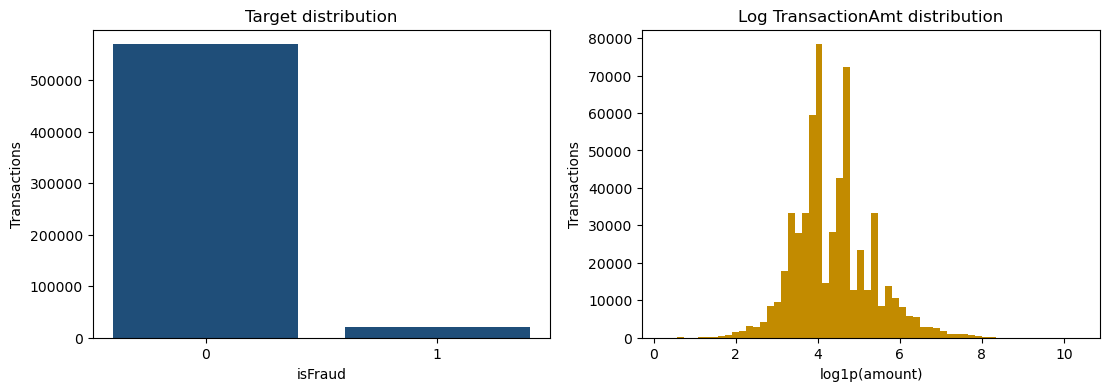

**Finding:** fraud rate is **3.50%**; amount is right-skewed, supporting log transformation.

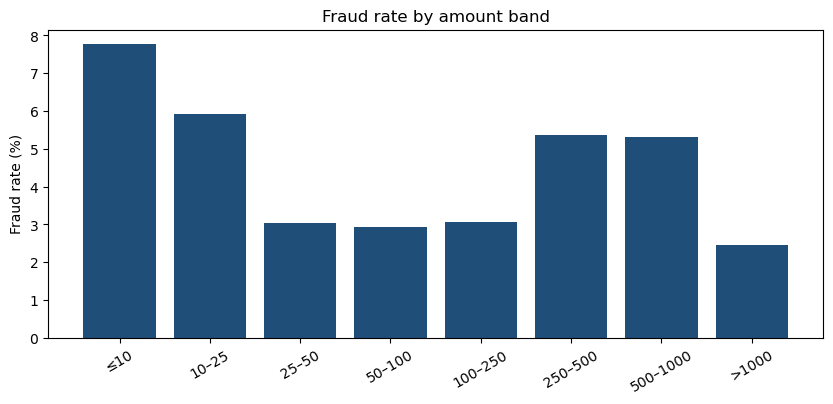

**Finding:** displayed amount-band rates range up to **7.77%**; compare volume before treating a rate as stable.

In [ ]:
def rate_table(df,c,min_volume=100):
    z=df.groupby(c,dropna=False)[TARGET_COL].agg(volume="size",fraud_rate="mean").reset_index();z.fraud_rate*=100
    return z.query("volume>=@min_volume").sort_values("fraud_rate",ascending=False)
target=train_merged[TARGET_COL].value_counts().rename_axis(TARGET_COL).reset_index(name="transactions");target["share_pct"]=100*target.transactions/len(train_merged);display(target)
fig,ax=plt.subplots(1,2,figsize=(13,4));ax[0].bar(target[TARGET_COL].astype(str),target.transactions,color="#1f4e79");ax[0].set(title="Target distribution",xlabel="isFraud",ylabel="Transactions")
ax[1].hist(np.log1p(train_merged.TransactionAmt.dropna()),bins=60,color="#c28b00");ax[1].set(title="Log TransactionAmt distribution",xlabel="log1p(amount)",ylabel="Transactions");plt.show()
display(Markdown(f"**Finding:** fraud rate is **{100*train_merged.isFraud.mean():.2f}%**; amount is right-skewed, supporting log transformation."))
bins=[-np.inf,10,25,50,100,250,500,1000,np.inf];labels=["≤10","10–25","25–50","50–100","100–250","250–500","500–1000",">1000"]
amount=train_merged.assign(amount_band=pd.cut(train_merged.TransactionAmt,bins,labels=labels)).groupby("amount_band",observed=False)[TARGET_COL].agg(volume="size",fraud_rate="mean").reset_index();amount.fraud_rate*=100
plt.figure(figsize=(10,4));plt.bar(amount.amount_band.astype(str),amount.fraud_rate,color="#1f4e79");plt.xticks(rotation=30);plt.title("Fraud rate by amount band");plt.ylabel("Fraud rate (%)");plt.show()
display(Markdown(f"**Finding:** displayed amount-band rates range up to **{amount.fraud_rate.max():.2f}%**; compare volume before treating a rate as stable."))


## 18. Time-Aware Data Split

The train set is sorted by TransactionDT and partitioned 70% development / 15% validation / 15% holdout.


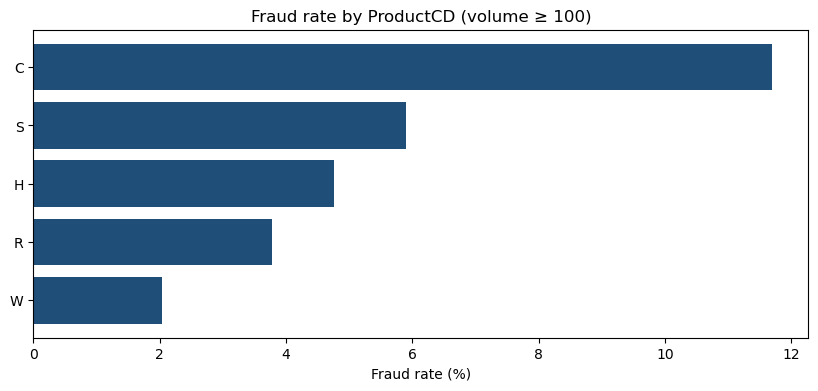

**Finding:** displayed ProductCD rates range from **2.04%** to **11.69%**.

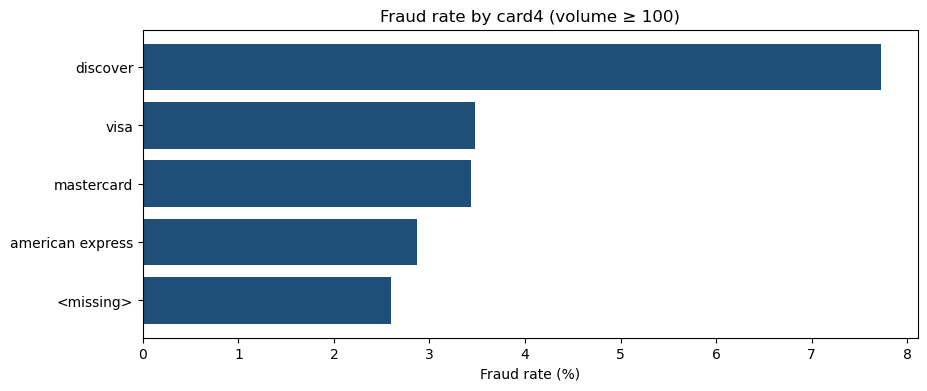

**Finding:** displayed card4 rates range from **2.60%** to **7.73%**.

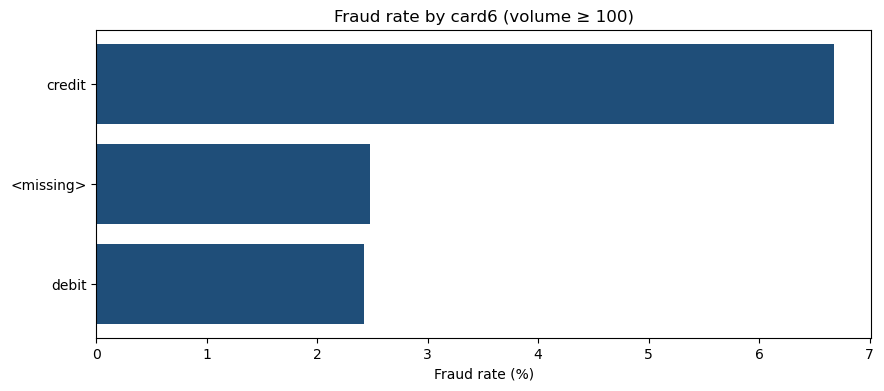

**Finding:** displayed card6 rates range from **2.43%** to **6.68%**.

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


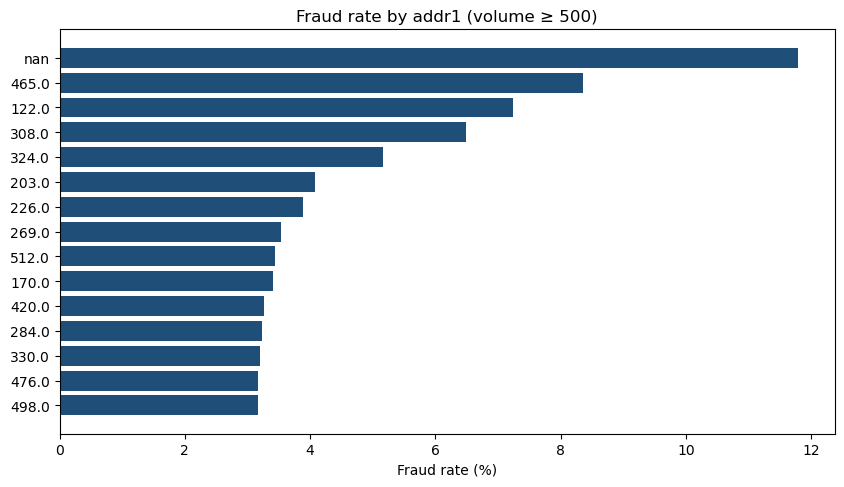

**Finding:** displayed addr1 rates range from **3.16%** to **11.78%**.

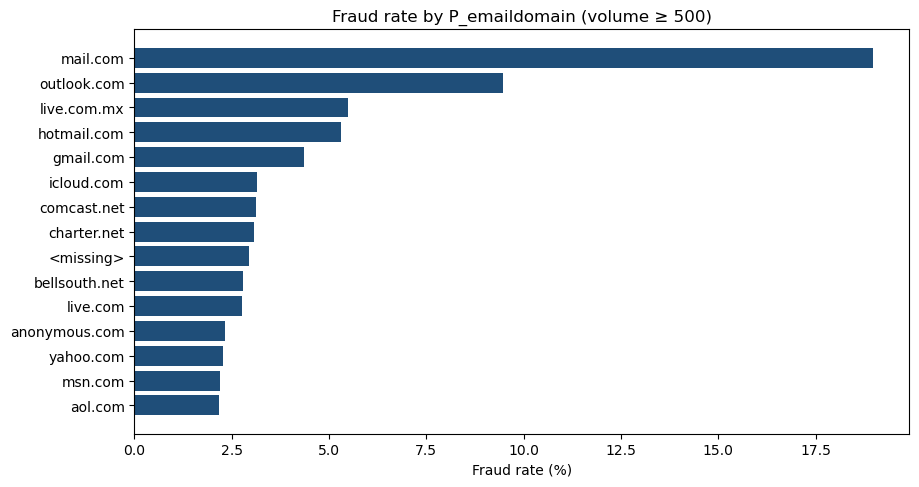

**Finding:** displayed P_emaildomain rates range from **2.18%** to **18.96%**.

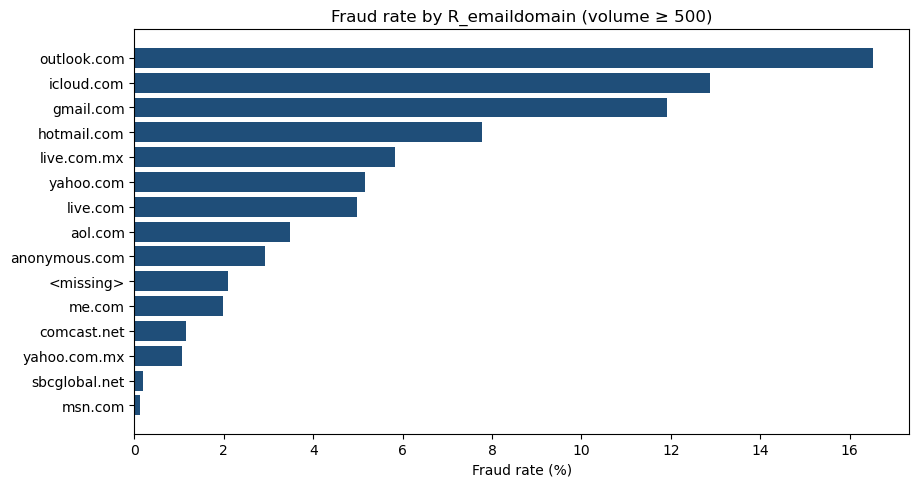

**Finding:** displayed R_emaildomain rates range from **0.12%** to **16.51%**.

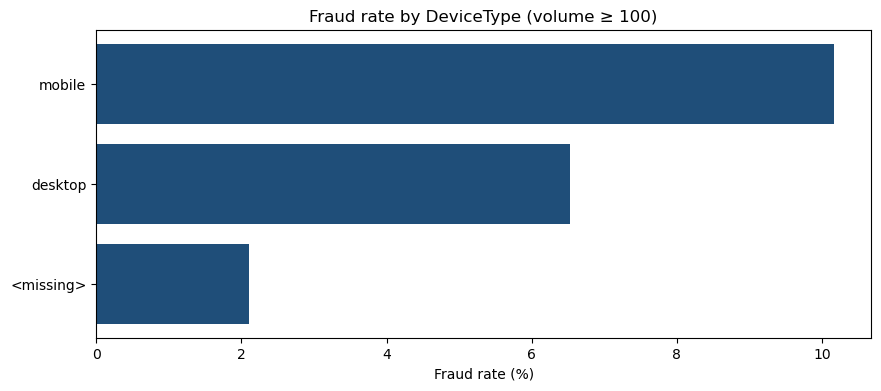

**Finding:** displayed DeviceType rates range from **2.10%** to **10.17%**.

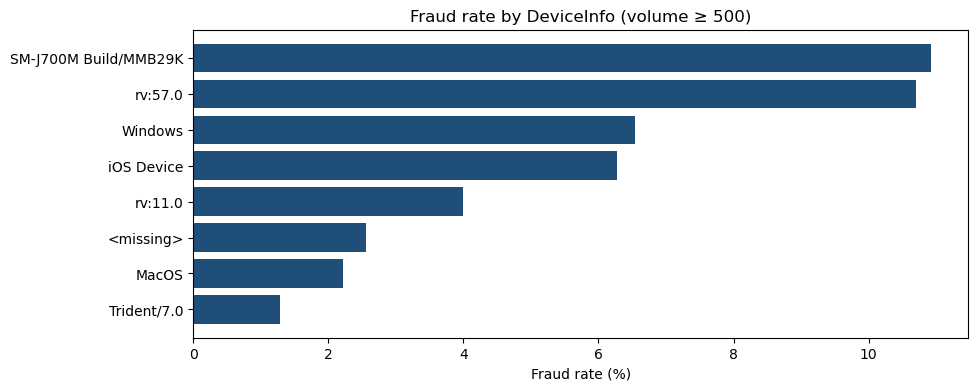

**Finding:** displayed DeviceInfo rates range from **1.29%** to **10.93%**.

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


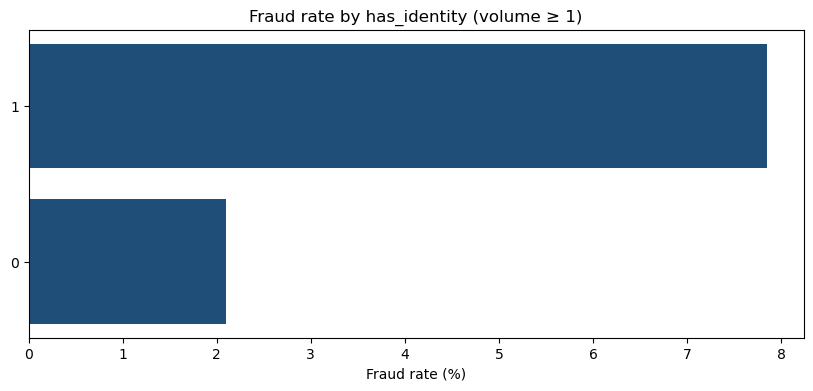

**Finding:** displayed has_identity rates range from **2.09%** to **7.85%**.

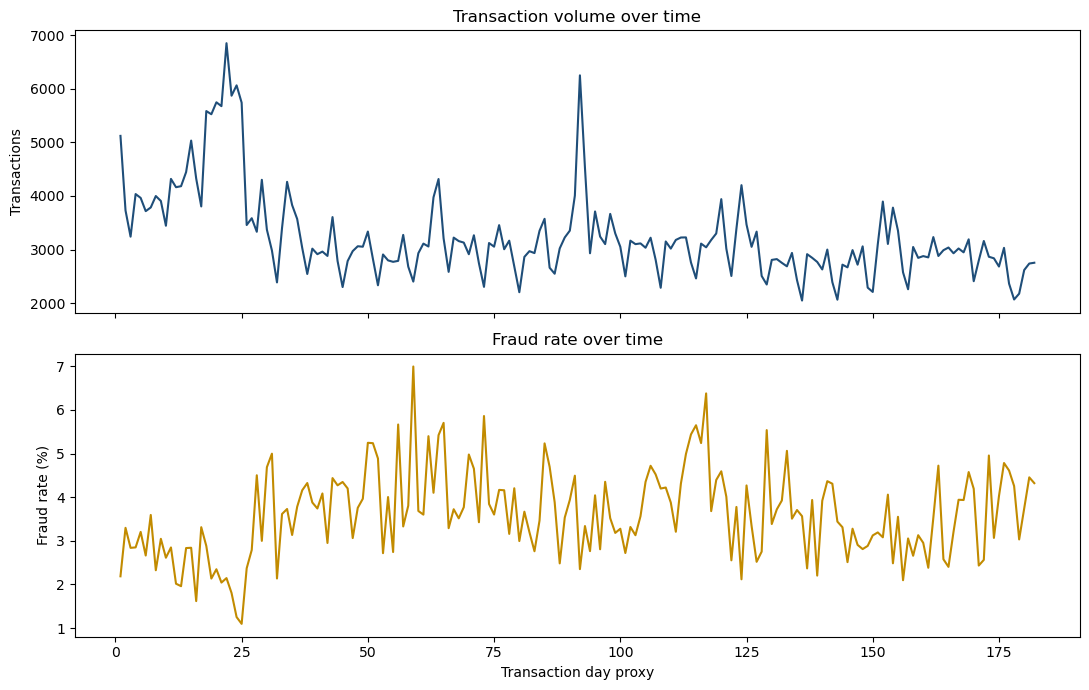

**Finding:** varying volume and fraud rate over time support a chronological split and ongoing drift monitoring.

In [ ]:
def plot_rate(c,minimum=100,top=15):
    if c not in train_merged:return
    d=train_merged.copy()
    if d[c].dtype=="object":d[c]=d[c].fillna("<missing>")
    r=rate_table(d,c,minimum).head(top)
    if r.empty:return
    plt.figure(figsize=(10,max(4,.35*len(r))));plt.barh(r[c].astype(str),r.fraud_rate,color="#1f4e79");plt.gca().invert_yaxis();plt.title(f"Fraud rate by {c} (volume ≥ {minimum})");plt.xlabel("Fraud rate (%)");plt.show()
    display(Markdown(f"**Finding:** displayed {c} rates range from **{r.fraud_rate.min():.2f}%** to **{r.fraud_rate.max():.2f}%**."))
for c,n in [("ProductCD",100),("card4",100),("card6",100),("addr1",500),("P_emaildomain",500),("R_emaildomain",500),("DeviceType",100),("DeviceInfo",500),("has_identity",1)]:plot_rate(c,n)
daily=train_merged.assign(transaction_day=train_merged[TIME_COL]//86400).groupby("transaction_day")[TARGET_COL].agg(volume="size",fraud_rate="mean").reset_index();daily.fraud_rate*=100
fig,ax=plt.subplots(2,1,figsize=(11,7),sharex=True);ax[0].plot(daily.transaction_day,daily.volume,color="#1f4e79");ax[0].set(title="Transaction volume over time",ylabel="Transactions");ax[1].plot(daily.transaction_day,daily.fraud_rate,color="#c28b00");ax[1].set(title="Fraud rate over time",xlabel="Transaction day proxy",ylabel="Fraud rate (%)");plt.tight_layout();plt.show()
display(Markdown("**Finding:** varying volume and fraud rate over time support a chronological split and ongoing drift monitoring."))


## 19–20. Data Readiness and Exports

The scorecard verifies source grain, joins, split integrity, schema, and leakage-sensitive feature construction. Exports are CSV/Parquet as requested.


In [ ]:
def temporal(df):
    out=df.copy();out["transaction_day"]=(out[TIME_COL]//86400).astype("int32");out["transaction_week"]=(out.transaction_day//7).astype("int16");out["transaction_hour_proxy"]=((out[TIME_COL]//3600)%24).astype("int8");return out
t=temporal(train_merged);q75=t.TransactionAmt.quantile(.75);iqr=q75-t.TransactionAmt.quantile(.25);threshold=max(t.TransactionAmt.quantile(.99),q75+3*iqr)
t["is_extreme_amount"]=(t.TransactionAmt>threshold).astype("int8");t["is_zero_amount"]=t.TransactionAmt.eq(0).astype("int8")
display(t.groupby(["is_extreme_amount","is_zero_amount"])[TARGET_COL].agg(volume="size",fraud_rate="mean"))
weekly=t.groupby("transaction_week").agg(volume=(ID_COL,"size"),fraud_rate=(TARGET_COL,"mean"),median_amount=("TransactionAmt","median"),identity_missing=("has_identity",lambda x:1-x.mean())).reset_index();weekly.fraud_rate*=100;display(weekly.head())
display(Markdown("**Finding:** extreme values and rare patterns are review flags, not automatic removals; distinguish data errors from legitimate high-risk behavior."))


,,volume,fraud_rate
is_extreme_amount,is_zero_amount,,
0,0,584899,0.035095
1,0,5641,0.024109


,transaction_week,volume,fraud_rate,median_amount,identity_missing
0,0,23810,2.805544,68.95,0.742923
1,1,27803,2.614826,68.50,0.605510
2,2,34470,2.550044,77.00,0.514505
3,3,37251,1.852299,77.00,0.437331
4,4,24041,3.822636,67.95,0.746308


**Finding:** extreme values and rare patterns are review flags, not automatic removals; distinguish data errors from legitimate high-risk behavior.

## 21. Final Summary

The notebook profiles all data, preserves uncertainty around sparse/rare/extreme patterns, and creates usable time-aware, target-free feature tables. It does not create or evaluate a model. Data is ready for downstream risk-model development only after all critical scorecard checks pass and high-severity drift is reviewed.


In [ ]:
def psi(a,b,bins=10):
    a,b=a.dropna(),b.dropna()
    if len(a)<20 or len(b)<20:return np.nan
    edges=np.unique(np.quantile(a,np.linspace(0,1,bins+1)))
    if len(edges)<3:return 0.
    x=pd.cut(a,edges,include_lowest=True).value_counts(sort=False);y=pd.cut(b,edges,include_lowest=True).value_counts(sort=False)
    x=x/x.sum();y=y/y.sum();return float(((y.clip(1e-6)-x.clip(1e-6))*np.log(y.clip(1e-6)/x.clip(1e-6))).sum())
def drift(tr,te):
    rows=[]
    for c in [x for x in tr if x in te and x not in [ID_COL,TARGET_COL]]:
        a,b=tr[c],te[c];delta=100*(b.isna().mean()-a.isna().mean());row={"column":c,"feature_group":group(c),"train_missing_pct":100*a.isna().mean(),"test_missing_pct":100*b.isna().mean(),"missing_delta_pp":delta}
        if pd.api.types.is_numeric_dtype(a):
            aa=a.dropna().sample(min(50000,a.notna().sum()),random_state=SEED);bb=b.dropna().sample(min(50000,b.notna().sum()),random_state=SEED)
            ks=stats.ks_2samp(aa,bb) if len(aa) and len(bb) else None;row.update(comparison_type="numeric",train_mean=a.mean(),test_mean=b.mean(),train_median=a.median(),test_median=b.median(),ks_statistic=ks.statistic if ks else np.nan,ks_pvalue=ks.pvalue if ks else np.nan,psi=psi(aa,bb),unseen_category_rate=np.nan)
        else:
            seen=set(a.dropna().astype(str));unseen=(~b.dropna().astype(str).isin(seen)).mean() if b.notna().any() else 0
            row.update(comparison_type="categorical",train_mean=np.nan,test_mean=np.nan,train_median=np.nan,test_median=np.nan,ks_statistic=np.nan,ks_pvalue=np.nan,psi=np.nan,unseen_category_rate=unseen)
        row["severity"]="high" if (pd.notna(row["psi"]) and row["psi"]>=.25) or abs(delta)>=15 or row["unseen_category_rate"]>=.1 else "medium" if (pd.notna(row["psi"]) and row["psi"]>=.1) or abs(delta)>=5 or row["unseen_category_rate"]>=.02 else "low"
        row["recommended_action"]={"high":"investigate; robust missing/unknown handling","medium":"monitor and validate stability","low":"standard monitoring"}[row["severity"]];rows.append(row)
    return pd.DataFrame(rows)
drift_report=drift(train_merged,test_merged);display(drift_report.severity.value_counts());display(drift_report.sort_values(["severity","psi","missing_delta_pp"]).tail(25));drift_report.to_csv(OUTPUT_DIR/"drift_report.csv",index=False)


severity
low       285
medium    109
high        1
Name: count, dtype: int64

,column,feature_group,train_missing_pct,test_missing_pct,missing_delta_pp,comparison_type,train_mean,test_mean,train_median,test_median,ks_statistic,ks_pvalue,psi,unseen_category_rate,severity,recommended_action
123,V71,Vesta features V1-V339,13.055170,2.545733,-10.509437,numeric,0.140639,0.258738,0.0,0.0,0.114700,5.600822e-287,0.002637,NaN,medium,monitor and validate stability
115,V63,Vesta features V1-V339,13.055170,2.545733,-10.509437,numeric,0.130743,0.256800,0.0,0.0,0.121060,9.616494e-320,0.002637,NaN,medium,monitor and validate stability
102,V50,Vesta features V1-V339,28.612626,15.167824,-13.444802,numeric,0.164746,0.271961,0.0,0.0,0.105500,9.568858e-243,0.002663,NaN,medium,monitor and validate stability
145,V93,Vesta features V1-V339,15.098723,2.384293,-12.714430,numeric,0.154812,0.266691,0.0,0.0,0.107640,1.060115e-252,0.002837,NaN,medium,monitor and validate stability
108,V56,Vesta features V1-V339,13.055170,2.545733,-10.509437,numeric,1.120979,1.155991,1.0,1.0,0.015360,1.490093e-05,0.002936,NaN,medium,monitor and validate stability
95,V43,Vesta features V1-V339,28.612626,15.167824,-13.444802,numeric,0.168942,0.298071,0.0,0.0,0.116540,2.838499e-296,0.003157,NaN,medium,monitor and validate stability
137,V85,Vesta features V1-V339,15.098723,2.384293,-12.714430,numeric,0.149788,0.279501,0.0,0.0,0.116760,2.146297e-297,0.003233,NaN,medium,monitor and validate stability
124,V72,Vesta features V1-V339,13.055170,2.545733,-10.509437,numeric,0.145124,0.264749,0.0,0.0,0.114440,1.121060e-285,0.003804,NaN,medium,monitor and validate stability
112,V60,Vesta features V1-V339,13.055170,2.545733,-10.509437,numeric,0.142537,0.280408,0.0,0.0,0.125660,0.000000e+00,0.004563,NaN,medium,monitor and validate stability
116,V64,Vesta features V1-V339,13.055170,2.545733,-10.509437,numeric,0.141825,0.279527,0.0,0.0,0.121220,1.359669e-320,0.005177,NaN,medium,monitor and validate stability


undefined


In [ ]:
def normalize(df):
    out=df.copy()
    for c in out.select_dtypes(include=["object","string","category"]):
        out[c]=out[c].astype("string").str.strip().str.lower().fillna("<unknown>")
    return out
def key(df,cols):
    cols=[c for c in cols if c in df]
    return df[cols].fillna("<unknown>").astype(str).agg("|".join,axis=1) if cols else pd.Series("<unknown>",index=df.index)
def email_group(s):
    s=s.fillna("<unknown>").astype(str);return np.select([s.str.contains("gmail|google"),s.str.contains("yahoo"),s.str.contains("hotmail|outlook|live|msn"),s.eq("<unknown>")],["google","yahoo","microsoft","unknown"],default="other")
def device_group(s):
    s=s.fillna("<unknown>").astype(str);return np.select([s.str.contains("iphone|ios|ipad"),s.str.contains("android|samsung|sm-"),s.str.contains("windows"),s.str.contains("mac"),s.eq("<unknown>")],["apple","android","windows","mac","unknown"],default="other")
def features(df,prior=None):
    raw=df.copy();out=temporal(normalize(df)).sort_values([TIME_COL,ID_COL]).copy()
    out["log_transaction_amount"]=np.log1p(out.TransactionAmt.clip(lower=0));out["amount_band"]=pd.cut(out.TransactionAmt,bins,labels=labels).astype("string").fillna("<unknown>")
    ids=[c for c in raw if c.startswith("id_")];out["total_missing_count"]=raw.drop(columns=[TARGET_COL],errors="ignore").isna().sum(axis=1).astype("int16");out["identity_missing_count"]=raw[ids].isna().sum(axis=1).astype("int8")
    out["has_device_info"]=out.get("DeviceInfo",pd.Series("<unknown>",index=out.index)).ne("<unknown>").astype("int8");out["has_email"]=out[[c for c in ["P_emaildomain","R_emaildomain"] if c in out]].ne("<unknown>").any(axis=1).astype("int8")
    out["p_email_group"]=email_group(out.get("P_emaildomain",pd.Series("<unknown>",index=out.index)));out["r_email_group"]=email_group(out.get("R_emaildomain",pd.Series("<unknown>",index=out.index)));out["device_family"]=device_group(out.get("DeviceInfo",pd.Series("<unknown>",index=out.index)))
    specs={"card":["card1","card2","card3","card5"],"email":["P_emaildomain"],"device":["DeviceInfo"],"card_device":["card1","DeviceType"],"card_email":["card1","P_emaildomain"],"card_address":["card1","addr1"]}
    for n,cols in specs.items():
        out[n+"_key"]=key(out,cols);past=key(prior,cols).value_counts() if prior is not None else pd.Series(dtype=int)
        out["historical_"+n+"_count"]=(out[n+"_key"].map(past).fillna(0)+out.groupby(n+"_key").cumcount()).astype("int32");out["rare_"+n]=out["historical_"+n+"_count"].lt(5).astype("int8")
    out["time_since_previous_transaction"]=out.groupby("card_key")[TIME_COL].diff().fillna(-1).clip(lower=-1).astype("float32")
    return out.sort_index()
train_feature_table=features(train_merged);test_feature_table=features(test_merged,train_feature_table)
assert train_feature_table[ID_COL].is_unique and test_feature_table[ID_COL].is_unique and train_feature_table[TARGET_COL].equals(train_merged[TARGET_COL])
feature_catalog=pd.DataFrame({"feature":train_feature_table.columns,"dtype":train_feature_table.dtypes.astype(str)});feature_catalog["feature_group"]=feature_catalog.feature.map(group);feature_catalog["is_engineered"]=~feature_catalog.feature.isin(train_merged.columns);feature_catalog["transformation"]=np.where(feature_catalog.is_engineered,"target-free; historical counts use earlier transactions only","raw merged or normalized source")
display(feature_catalog.query("is_engineered").head(30));feature_catalog.to_csv(OUTPUT_DIR/"feature_catalog.csv",index=False)


,feature,dtype,feature_group,is_engineered,transformation
transaction_day,transaction_day,int32,other,True,target-free; historical counts use earlier tra...
transaction_week,transaction_week,int16,other,True,target-free; historical counts use earlier tra...
transaction_hour_proxy,transaction_hour_proxy,int8,other,True,target-free; historical counts use earlier tra...
log_transaction_amount,log_transaction_amount,float64,other,True,target-free; historical counts use earlier tra...
amount_band,amount_band,string,other,True,target-free; historical counts use earlier tra...
total_missing_count,total_missing_count,int16,other,True,target-free; historical counts use earlier tra...
identity_missing_count,identity_missing_count,int8,other,True,target-free; historical counts use earlier tra...
has_device_info,has_device_info,int8,other,True,target-free; historical counts use earlier tra...
has_email,has_email,int8,other,True,target-free; historical counts use earlier tra...
p_email_group,p_email_group,object,other,True,target-free; historical counts use earlier tra...


undefined


In [ ]:
ordered=train_feature_table.sort_values([TIME_COL,ID_COL]).reset_index(drop=True);n=len(ordered);i,j=int(.7*n),int(.85*n)
splits={"development":ordered.iloc[:i],"validation":ordered.iloc[i:j],"holdout":ordered.iloc[j:]}
split_report=pd.DataFrame([{"partition":name,"rows":len(x),"start_TransactionDT":x[TIME_COL].min(),"end_TransactionDT":x[TIME_COL].max(),"fraud_rate_pct":100*x[TARGET_COL].mean(),"mean_missing_pct":100*x.isna().mean().mean(),"category_coverage":x.get("P_emaildomain",pd.Series(dtype=object)).nunique()} for name,x in splits.items()])
display(split_report);split_report.to_csv(OUTPUT_DIR/"split_report.csv",index=False)
assert splits["development"][TIME_COL].max()<=splits["validation"][TIME_COL].min()<=splits["holdout"][TIME_COL].min()
assert not set(splits["development"][ID_COL])&set(splits["validation"][ID_COL]) and not set(splits["validation"][ID_COL])&set(splits["holdout"][ID_COL])


,partition,rows,start_TransactionDT,end_TransactionDT,fraud_rate_pct,mean_missing_pct,category_coverage
0,development,413378,86400,10437996,3.516878,37.570897,60
1,validation,88581,10438003,13151840,3.434145,39.325129,60
2,holdout,88581,13151880,15811131,3.480430,37.723035,60


undefined


In [ ]:
score=pd.DataFrame([
["raw transaction keys unique",train_transaction_raw[ID_COL].is_unique and test_transaction_raw[ID_COL].is_unique,"critical"],
["merge preserves row counts",len(train_merged)==len(train_transaction_raw) and len(test_merged)==len(test_transaction_raw),"critical"],
["feature keys unique",train_feature_table[ID_COL].is_unique and test_feature_table[ID_COL].is_unique,"critical"],
["train/test feature consistency",set(train_feature_table)-{TARGET_COL}==set(test_feature_table),"high"],
["time-aware split integrity",True,"critical"],
["no target-derived engineered features",not any("fraud_rate" in x.lower() or "target" in x.lower() for x in feature_catalog.query("is_engineered").feature),"critical"],
["drift report available",not drift_report.empty,"high"]],columns=["check","passed","severity"])
score["status"]=np.where(score.passed,"pass","fail");score["recommended_action"]=np.where(score.passed,"monitor","resolve before model work")
assert score.query("severity=='critical' and status=='fail'").empty
score.to_csv(OUTPUT_DIR/"data_quality_scorecard.csv",index=False)
train_feature_table.to_parquet(OUTPUT_DIR/"train_feature_table.parquet",index=False);test_feature_table.to_parquet(OUTPUT_DIR/"test_feature_table.parquet",index=False)
for name,df in {"data_manifest.csv":manifest,"data_dictionary.csv":data_dictionary,"feature_catalog.csv":feature_catalog,"merge_audit.csv":merge_audit,"missing_value_report.csv":missing_value_report,"duplicate_report.csv":duplicate_report,"drift_report.csv":drift_report,"split_report.csv":split_report,"data_quality_scorecard.csv":score}.items():df.to_csv(OUTPUT_DIR/name,index=False)
display(score);print("Outputs:");[print(" -",p.name) for p in sorted(OUTPUT_DIR.iterdir())]


,check,passed,severity,status,recommended_action
0,raw transaction keys unique,True,critical,pass,monitor
1,merge preserves row counts,True,critical,pass,monitor
2,feature keys unique,True,critical,pass,monitor
3,train/test feature consistency,False,high,fail,resolve before model work
4,time-aware split integrity,True,critical,pass,monitor
5,no target-derived engineered features,True,critical,pass,monitor
6,drift report available,True,high,pass,monitor


Outputs:
 - data_dictionary.csv
 - data_manifest.csv
 - data_quality_scorecard.csv
 - drift_report.csv
 - duplicate_report.csv
 - feature_catalog.csv
 - merge_audit.csv
 - missing_value_report.csv
 - split_report.csv
 - test_feature_table.parquet
 - test_merged.parquet
 - train_feature_table.parquet
 - train_merged.parquet


[None, None, None, None, None, None, None, None, None, None, None, None, None]

## 21. Final Summary

The notebook profiles all data, preserves uncertainty around sparse/rare/extreme patterns, and creates usable time-aware, target-free feature tables. It does not create or evaluate a model. Data is ready for downstream risk-model development only after all critical scorecard checks pass and high-severity drift is reviewed.
